In [1]:
import sys
sys.path.append('../lib/')
import numpy as np
import healpy as hp
import pysm3
import pysm3.units as u
import pymaster as nmt
import matplotlib.pyplot as plt
from tqdm import trange
import basicfunc as func
import simu_lib as sim

In [2]:
# PySM model to consider, d#s#

dust_type = 12
sync_type = 7
nside_pysm = 512

nside = 64
Npix = hp.nside2npix(nside)
lmax = 2*nside-1
Nlbin = 10

# Reference frequencies in GHz

nu0d = 402
nu0s = 40

In [79]:
# Compute dust moments maps

GAL080 = hp.read_map('HFI_Mask_GalPlane-apo0_2048_R2.00.fits', field=4)
GAL080 = hp.ud_grade(GAL080, nside_pysm)
GAL080[GAL080<0.5], GAL080[GAL080>0.5] = 0, 1

GAL080_dg = hp.ud_grade(np.float64(GAL080), nside)
GAL080_dg[GAL080_dg<0.5], GAL080_dg[GAL080_dg>0.5] = 0, 1

sky = pysm3.Sky(nside_pysm, preset_strings=[f'd{dust_type}'], output_unit=u.uK_CMB)
dust = sky.components[0]
beta_map = dust.mbb_index.value
T_map = dust.mbb_temperature.value

if dust_type == 12:
    A_map = dust.layers.value
    A_complex = (A_map[:,1] + 1j * A_map[:,2]) * func.unit_conversion(353, input_unit='uK_RJ', output_unit='uK_CMB') / func.mbb_uK(353, beta_map, 1/T_map, nu0=nu0d)
else:
    A_map = sky.get_emission(nu0d * u.GHz).value
    A_complex = np.array([A_map[1] + 1j * A_map[2]])
    beta_map = np.array([beta_map])
    T_map = np.array([T_map])

beta_bar = np.average(beta_map[np.array([GAL080 for i in range(len(A_complex))])==1], weights=A_complex[np.array([GAL080 for i in range(len(A_complex))])==1]).real
T_bar = 1 / np.average(1/T_map[np.array([GAL080 for i in range(len(A_complex))])==1], weights=A_complex[np.array([GAL080 for i in range(len(A_complex))])==1]).real

w2b = np.sum(A_complex * (beta_map-beta_bar)**2, axis=0)

In [80]:
beta_bar, T_bar

(np.float64(1.5933059309472521), np.float64(18.791754517266654))

In [81]:
w2b_IQU = np.array([np.zeros_like(w2b.real), w2b.real, w2b.imag])
w2b_IQU = hp.smoothing(w2b_IQU, np.radians(3))
w2b_B = hp.alm2map(hp.map2alm(w2b_IQU * GAL080)[2], nside=nside_pysm)

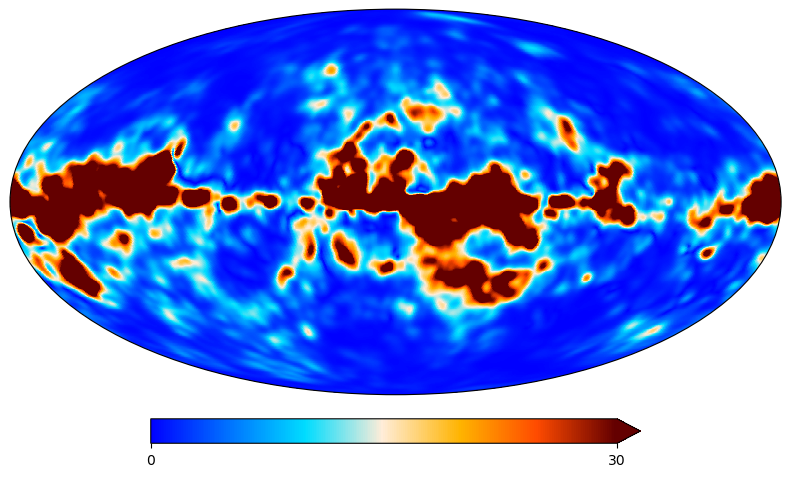

In [82]:
hp.projview(np.sqrt(np.sum(w2b_IQU[1:]**2, axis=0)), min=0, max=30, cmap='planck')
plt.show()

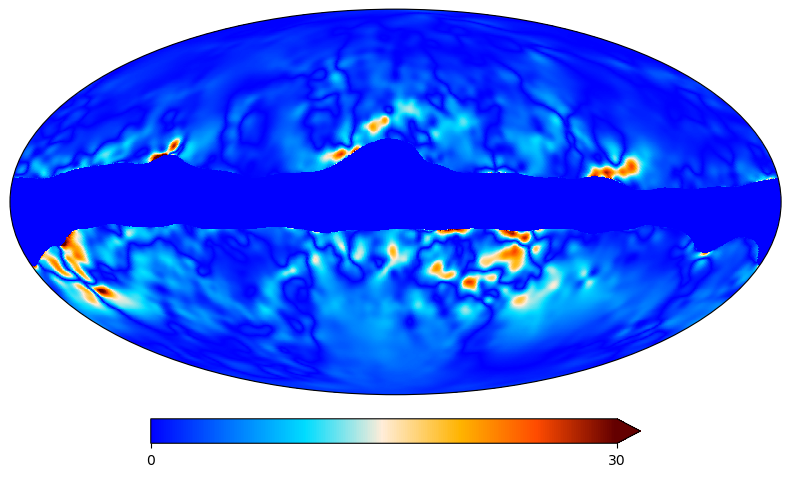

In [87]:
hp.projview(np.abs(w2b_B * GAL080), min=0, max=30, cmap='planck')
plt.show()

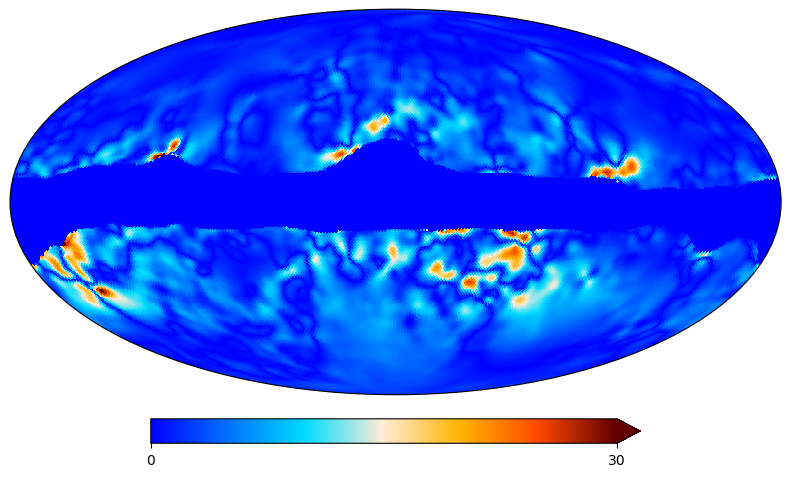

In [88]:
w2b_dg = hp.ud_grade(w2b_B, nside)
hp.projview(np.abs(w2b_dg*GAL080_dg), min=0, max=30, cmap='planck')
plt.show()

In [258]:
w2b_dg[GAL080_dg==0] = 0

fsky = 0.666
threshold = np.quantile(np.abs(w2b_dg), 1 - (np.mean(GAL080**2) - fsky))

mask2 = np.ones(Npix)
mask2[np.abs(w2b_dg) > threshold] = 0

In [259]:
threshold

np.float64(6.29343625560684)

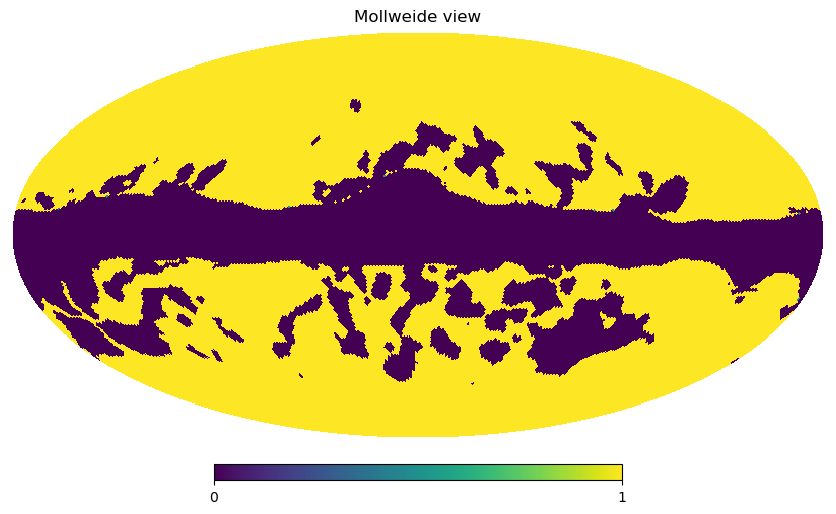

In [260]:
hp.mollview(GAL080_dg * mask2)
plt.show()

In [261]:
np.mean((GAL080_dg * mask2)**2)

np.float64(0.66595458984375)

In [262]:
#fsky = 0.6

#mask2 = hp.smoothing(mask*GAL070_dg, np.radians(10))
#mask2 = mask * GAL070_dg
#threshold = np.quantile(mask2, 1-fsky)
#mask2[mask2<threshold], mask2[mask2>threshold] = 0, 1

alm_mask = hp.map2alm(mask2)
lmax_in = 3*nside-1
lmax_out = int(180 / 25)

alm_mask_lp = np.zeros_like(alm_mask, dtype=complex)

for m in range(lmax_out+1):
    idx_1 = hp.sphtfunc.Alm.getidx(lmax_in, m, m)
    idx_2 = hp.sphtfunc.Alm.getidx(lmax_in, lmax_out, m)

    alm_mask_lp[idx_1:idx_2+1] = alm_mask[idx_1:idx_2+1]

mask2_lp = hp.alm2map(alm_mask_lp, nside=nside)
mask2_lp[mask2_lp<0.5], mask2_lp[mask2_lp>0.5] = 0, 1

mask = GAL080_dg * mask2_lp

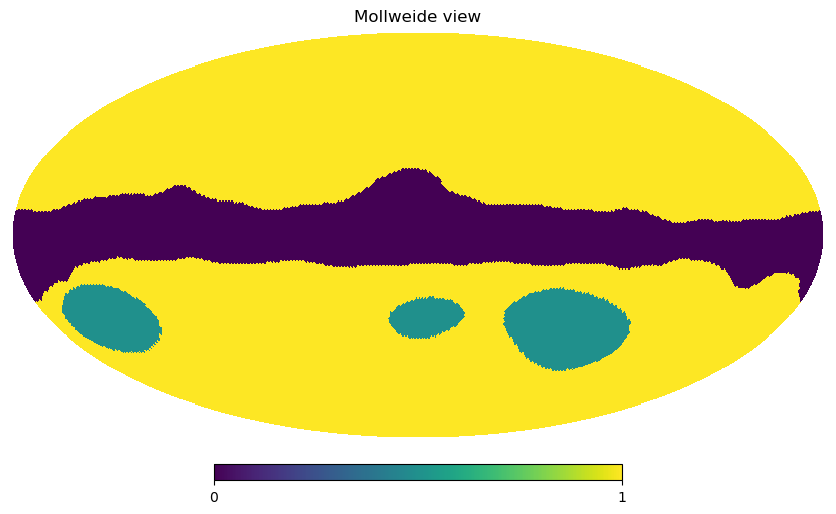

In [263]:
masks = np.ones(Npix)
masks[mask2_lp==0], masks[GAL080_dg==0] = 0.5, 0
hp.mollview(masks)
plt.show()

In [264]:
np.mean(mask**2)

np.float64(0.7412923177083334)

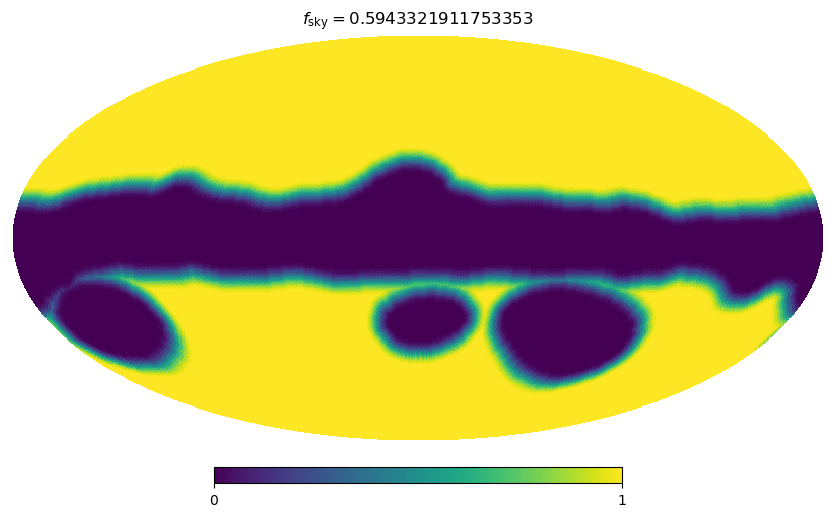

In [265]:
mask_apod = nmt.mask_apodization(mask, aposize=10, apotype='C2')
hp.mollview(mask_apod, title=r'$f_{\rm sky} = %s$' % np.mean(mask_apod**2))
plt.show()

In [266]:
# Test on CMB only

N = 100
lmax = 2*nside-1
Nlbin = 10

b = nmt.NmtBin.from_lmax_linear(lmax, nlb=Nlbin, is_Dell=True)
leff = b.get_effective_ells()
Nbins = len(leff)

Cl_CMB = hp.read_cl('../power_spectra/Cls_LiteBIRD_e2e_r0.fits')
Dl_CMB = b.bin_cell(Cl_CMB[2, :lmax+1])
Dl_BB = np.zeros((N, Nbins))

f = nmt.NmtField(mask_apod, None, spin=2, lmax=lmax, purify_b=True)
w = nmt.NmtWorkspace()
w.compute_coupling_matrix(f, f, b)

for i in trange(N):
    cmb = hp.synfast(Cl_CMB, nside, new=True)[1:]

    f = nmt.NmtField(mask_apod, cmb, purify_b=True)
    Cl_coupled = nmt.compute_coupled_cell(f, f)
    Dl_BB[i] = w.decouple_cell(Cl_coupled)[3]

100%|██████████| 100/100 [00:09<00:00, 10.36it/s]


In [267]:
# Planck 60% on CMB only

GAL070 = hp.read_map('mask_fsky0.7_nside64_aposcale10.npy')

N = 100
lmax = 2*nside-1
Nlbin = 10

b = nmt.NmtBin.from_lmax_linear(lmax, nlb=Nlbin, is_Dell=True)
leff = b.get_effective_ells()
Nbins = len(leff)

Cl_CMB = hp.read_cl('../power_spectra/Cls_LiteBIRD_e2e_r0.fits')
Dl_CMB = b.bin_cell(Cl_CMB[2, :lmax+1])
Dl_BB_GAL070 = np.zeros((N, Nbins))

f = nmt.NmtField(GAL070, None, spin=2, lmax=lmax, purify_b=True)
w = nmt.NmtWorkspace()
w.compute_coupling_matrix(f, f, b)

for i in trange(N):
    cmb = hp.synfast(Cl_CMB, nside, new=True)[1:]

    f = nmt.NmtField(GAL070, cmb, purify_b=True)
    Cl_coupled = nmt.compute_coupled_cell(f, f)
    Dl_BB_GAL070[i] = w.decouple_cell(Cl_coupled)[3]

100%|██████████| 100/100 [00:09<00:00, 10.62it/s]


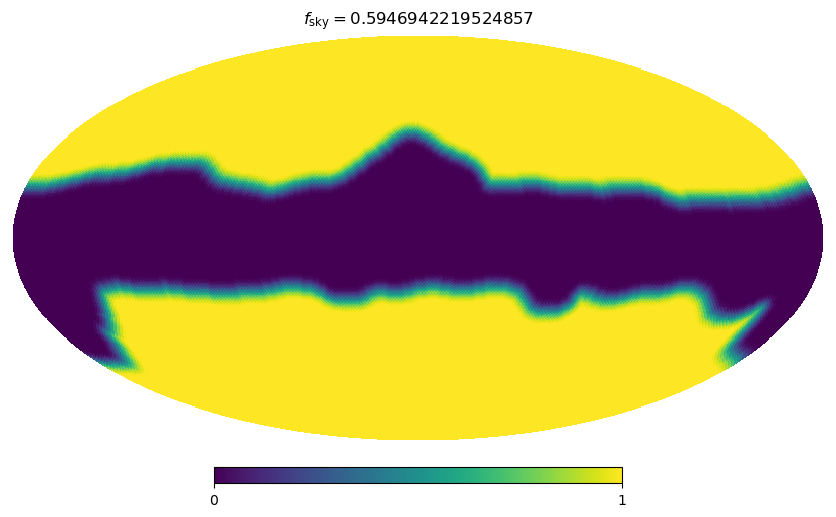

In [268]:
hp.mollview(GAL070, title=r'$f_{\rm sky} = %s$' % np.mean(GAL070**2))
plt.show()

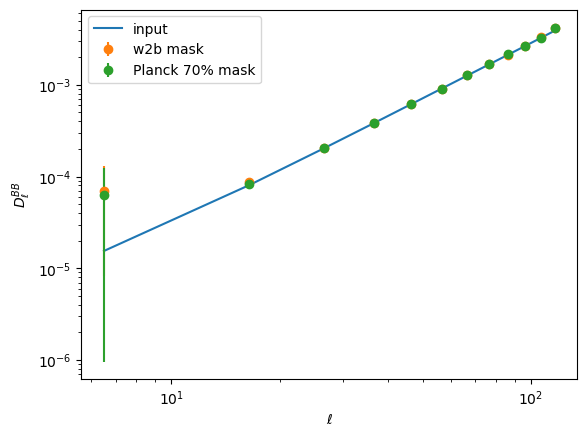

In [269]:
plt.plot(leff, Dl_CMB, label='input')
plt.errorbar(leff, np.mean(Dl_BB, axis=0), yerr=np.std(Dl_BB, axis=0), fmt='o', label='w2b mask')
plt.errorbar(leff, np.mean(Dl_BB_GAL070, axis=0), yerr=np.std(Dl_BB, axis=0), fmt='o', label='Planck 70% mask')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell^{BB}$')
plt.legend()

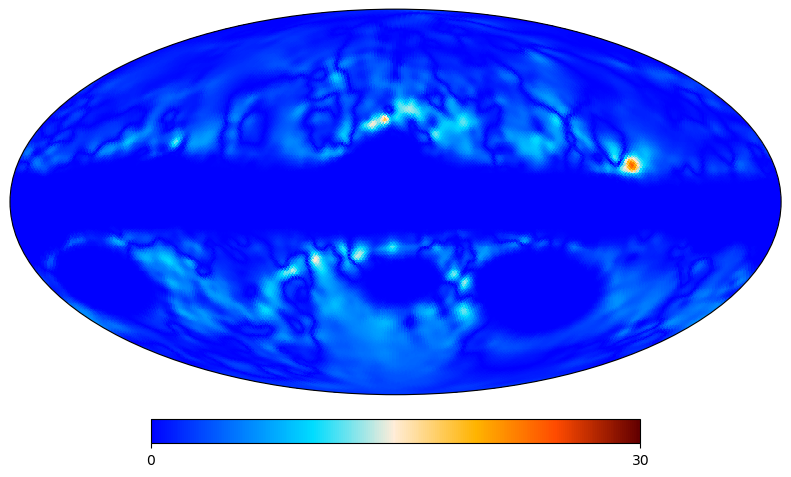

In [270]:
hp.projview(np.abs(w2b_dg*mask_apod), min=0, max=30, cmap='planck')
plt.show()

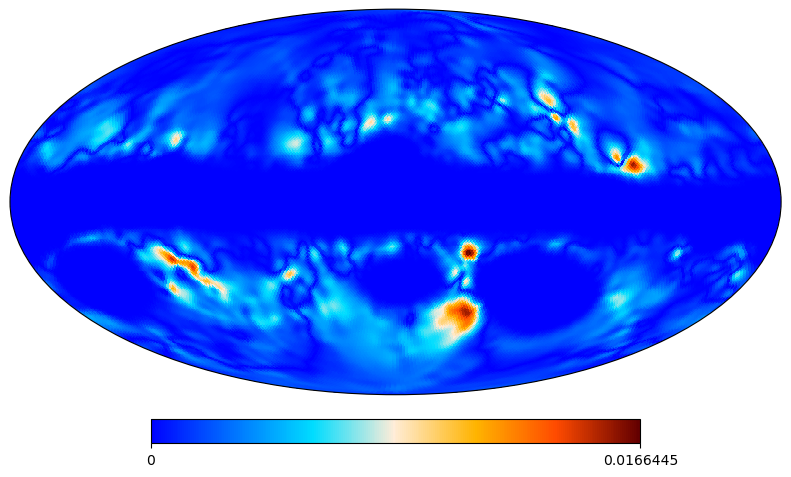

In [271]:
w2t = np.sum(A_complex * (1/T_map-1/T_bar)**2, axis=0)
w2t_IQU = np.array([np.zeros_like(w2t.real), w2t.real, w2t.imag])
w2t_IQU = hp.smoothing(w2t_IQU, np.radians(3))
w2t_B = hp.alm2map(hp.map2alm(w2t_IQU * GAL080)[2], nside=nside_pysm)
w2t_dg = hp.ud_grade(w2t_B, nside)

hp.projview(np.abs(w2t_dg*mask_apod), cmap='planck')
plt.show()

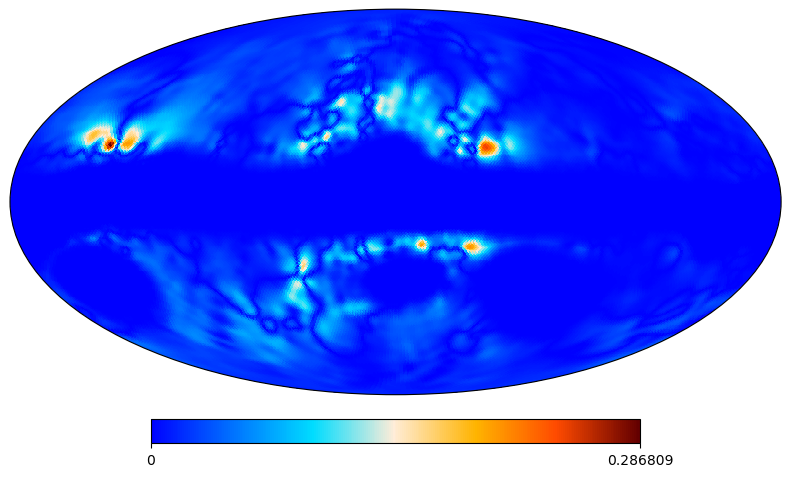

In [272]:
# Compute sync moments maps

sky = pysm3.Sky(nside_pysm, preset_strings=[f's{sync_type}'], output_unit=u.uK_CMB)
sync = sky.components[0]
betas_map = sync.pl_index.value
As_map = sky.get_emission(nu0s * u.GHz).value
As_complex = np.array([As_map[1] + 1j * As_map[2]])
betas_map = np.array([betas_map])
betas_bar = np.average(betas_map[0][GAL080==1], weights=As_complex[0][GAL080==1]).real

w2bs = np.sum(As_complex * (betas_map-betas_bar)**2, axis=0)
w2bs_IQU = np.array([np.zeros_like(w2bs.real), w2bs.real, w2bs.imag])
w2bs_IQU = hp.smoothing(w2bs_IQU, np.radians(3))
w2bs_B = hp.alm2map(hp.map2alm(w2bs_IQU * GAL080)[2], nside=nside_pysm)
w2bs_dg = hp.ud_grade(w2bs_B, nside)

hp.projview(np.abs(w2bs_dg*mask_apod), cmap='planck')
plt.show()

In [273]:
hp.write_map('mask_fsky0.7_w2b_high_nside64_aposcale10.npy', mask_apod, overwrite=True)

setting the output map dtype to [dtype('float64')]
